# Physics Informed Neural Networks for Mean Flow Reconstruction

# Overview
In this tutorial, Physics-Informed Neural Networks (PINNs) are used to reconstruct mean flow using the first-order flow statistics. A PyTorch implementation of the methodology set out by Sliwinski and Rigas $[1]$ has been provided, where sparse observational data is used to reconstruct the mean velocity fields of the canonical setting of 2D periodic hills at a Reynolds number of 5600, where flow features such as separation, recirculation and reattachment can be observed. The sparse observational data have been obtained from direct numerical simulation (DNS) data from Xiao et al. $[3]$.

### Learning Objectives

1. Understand the methodology behind PINNs and their use in mean flow reconstruction from sparse observational data.
2. Create and load the data required to train a PINN.
3. Tune the hyperparameters of a PINN using a simple grid search.
4. Train and post-process a PINN, and validate its performance by comparing the results with DNS data. 

### Tutorial Pipeline Flowchart

We provide a flowchart of the pipeline to aid throughout the tutorial:

<div>
<img src="img/Tutorial Flowchart.png" alt="Tutorial Flowchart" width="650"/>
</div>


## 1. Methodology 

### 1.1 Physics-Informed Neural Networks (PINNs)
PINNs are a type of neural network that can be trained to obey the governing equations of a PDE. These neural networks are trained to output the unknown field quantities from their spatio-temporal inputs. In the case of mean flow in 2 dimensions, these inputs are the $x$ and $y$ position in the domain, where these inputs are then passed through a neural network to obtain the respective flow fields.

In a supervised learning environment, labelled training data is used to optimise a set of weights and biases with respect to a loss between the true values and predicted values; however, these labelled data points can only be obtained at the initial and boundary conditions of the domain and any measured data. This results in poor performance outside of the support of these labelled data. To combat this, the governing equations of the underlying physics are used to constrain the PINNs solution by performing unsupervised learning at a set of unlabelled collocation points sampled in the domain. In this setting, a loss is obtained at the unlabelled collocation points by evaluating the governing equations. This is done by finding any partial derivatives with respect to the inputs necessary for the governing equations and is done automatically via automatic differentiation. The total loss from the supervised and unsupervised components is then obtained, where minimisation of this loss with respect to the parameters of the neural network is done to train the model. A schematic of how the residuals are evaluated is provided below:

<div>
<img src="img/PINN Schematic.png" alt="PINN Schematic" width="900"/>
</div>

Where, $()_x$ and $()_y$ refer to the partial derivatives with respect to $x$ and $y$ and the variables $\overline{U}$, $\overline{V}$, $\overline{P}-\phi$, $f_{us}$, $f_{vs}$ refer to the flow fields we wish to obtain using the PINN. 

### 1.2 Formulation of Reynolds-averaged Navier-Stokes Equations (RANS) for Flow Reconstruction
#### 1.2.1 RANS with Explicit Reynolds Stresses
In unsteady turbulent flows, applying a Reynolds decomposition of the flow fields into their first-order (mean-flow) and second-order (fluctuation) components can be used to obtain the governing equations (continuity and momentum). In the 2-dimensional case, for the following case setup, the following 3 governing equations for flow in 2 dimensions (continuity, x-momentum, y-momentum) can be obtained:
$$
\overline{U}_x + \overline{V}_y = 0
$$
$$
\overline{U}\overline{U}_x+ \overline{V}\overline{U}_y + \frac{1}{\rho}\overline{P}_x - \nu(\overline{U}_{xx} + \overline{U}_{yy}) +  (\overline{u'u'})_x + (\overline{u'v'})_y = 0 
$$
$$
\overline{U}\overline{V}_x+ \overline{V}\overline{V}_y + \frac{1}{\rho}\overline{P}_y - \nu(\overline{V}_{xx} + \overline{V}_{yy}) +  (\overline{u'v'})_x + (\overline{v'v'})_y = 0
$$

Where, $()_x$ and $()_y$ refer to the partial derivatives with respect to $x$ and $y$. This results in 3 governing equations, with the 6 unknown variables: $(\overline{U}, \overline{V}, \overline{P}, \overline{u'u'}, \overline{u'v'}, \overline{v'v'})$, resulting in an under-determined system. If the true velocity fields are known, which results in the continuity governing equation automatically being satisfied, 2 governing equations and 4 unknown variables are left: $(\overline{P}, \overline{u'u'}, \overline{u'v'}, \overline{v'v'})$. This leads to a determinate system only if the Reynolds stresses are known, resulting in 2 governing equations and 1 unknown. In the flow-reconstruction setting, where we only have sparse locations where the true velocity and Reynolds stress fields are known, the system is under-determined. However, as the system with the true velocity and Reynold stress fields is determinate the PINN given sparse data to interpolate between should be able to obtain an accurate solution.

#### 1.2.2 RANS with Forcing Vector as Reynolds Stresses
To remove the need for the second-order flow statistics in the sparse observational data, we decompose $\nabla\cdot\mathbf{\overline{u'u'}}$ via a Helmholtz decomposition into its potential and solenoidal (divergence-free) components:

$$
f \equiv -\nabla\cdot\mathbf{\overline{u'u'}}=  \frac{1}{\rho} \nabla\phi + f_s\\
$$

Where $f_s =  [f_{us}, f_{vs}]^T$. The resulting four governing equations can now be obtained:
$$
\overline{U}_x + \overline{V}_y = 0
$$
$$
\overline{U}\overline{U}_x+ \overline{V}\overline{U}_y + \frac{1}{\rho}(\overline{P}-\phi)_x - \nu(\overline{U}_{xx} + \overline{U}_{yy}) - f_{us}= 0
$$
$$
\overline{U}\overline{V}_x+ \overline{V}\overline{V}_y + \frac{1}{\rho}(\overline{P}-\phi)_y - \nu(\overline{V}_{xx} + \overline{V}_{yy}) - f_{vs} = 0
$$
$$
(f_{us})_x +(f_{vs})_y = 0
$$
As before, if the true velocity fields are known, where the continuity equations are automatically satisfied, 3 governing equations and 3 unknown variables remain: $(\overline{P}-\phi, f_{us}, f_{vs})$, leading to a determinate system. In the setting where only sparse measurements of the solution are available, the PINN should be able to obtain an accurate solution without the need for second-order velocity statistics being measured. It's important to note that the pressure field cannot be obtained, as the solution for the pressure field remains under-determined due to the unknown potential component being put together with the pressure term as a single variable.

This formulation of RANS is used for the remainder of the tutorial.

### 1.3 Pros and Cons
#### 1.3.1 Pros

- Mesh-free: PINNs use a set of discrete collocation points sampled within the domain of the problem.
- Performs well on ill-posed problems, such as problems with noisy measurement data.
- Explicit gradients for the solution fields are available (can be used for sensitivity analysis).
- Can solve both forward and inverse problems.

#### 1.3.2 Cons

- Poor performance in highly turbulent regions.
- Hyperparameter tuning can be expensive due to the many expensive training runs.


## 2. Case Setup

### Periodic Flows over Parameterised Hills

#### 2.1 Introduction to Case

In this tutorial, a PINN is used to reconstruct the mean-flow velocity field solution for 2D separating flows over periodic hills. Sparse data was obtained by sampling points on a grid from DNS data. This data has obtained by solving the forced Navier-stokes equations in the incompressible setting, a forcing field along the $x$-axis was also used to ensure specified mass-flow $[3]$. This data is used to emulate sparse experimental data and to compare the results from the trained PINN. For this tutorial, the flow is at Reynolds number 5600, based on the hill crest length $H$ and the bulk velocity at the crest $U_b$. The domain height is $L_y = 3.036H$. The streamwise length is: $L_x = 9H$. A schematic of the computational domain is shown below, with the boundaries labelled:

<div>
<img src="img/Periodic Hills.png" alt="Periodic Hills" width="800"/>
</div>

#### 2.2 Initial/Boundary Conditions
- ID 1: Periodic flow inlet, $U_b$ = 1 m/s
- ID 2: Hill wall, no-slip condition
- ID 3: Top wall, no-slip condition
- ID 4: Periodic flow outlet

#### 2.3 Link to Dataset:
- https://github.com/xiaoh/para-database-for-PIML 

# **Importing Libraries and Data**
## 1. Libraries (PyTorch, NumPy, Pandas, scipy, matplotlib)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import time
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import grad
from utils import plot_computational_domain, gen_hill_points, is_inside_domain, gen_sparse_grid, compare_flow_fields, print_loss_stats, plot_streamlines
from scipy.stats.qmc import Halton

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print('Device:', device, 'is being used')

Device: cuda:0 is being used


## 2. Data Representation

We first start by defining the parameters for the parameterised computational domain:

In [3]:
# Periodic Hills Geometry Parameters
alpha = 1.0
bottom_flat_length = 5.142
domain_height = 3.036

### 2.1 Generation of Input Data

#### 2.1.1 Generation of Inlet, Outlet, Wall Boundary Data Points, and Collocation Points
We define some helper functions to generate uniformly spaced data points along the boundary conditions of the case. We further define a function to sample points in the computational domain via a Halton scheme. 


In general, when sampling collocation points in the computational domain, it is best to use some kind of space-filling design to ensure points are well distributed, allowing the domain to be efficiently sampled while remaining an unbiased sample.

In [4]:
def gen_inlet_inputs(n, domain_height=3.036):
    
    # Generate n uniformly spaced points along inlet

    y = np.linspace(1,domain_height,n)
    x = np.zeros_like(y)
    return np.column_stack((x,y))

def gen_outlet_inputs(n, domain_height=3.036, alpha=1., bottom_flat_length=5.142):

    # Generate n uniformly spaced points along outlet

    streamwise_length = 3.858*alpha + bottom_flat_length
    y = np.linspace(1,domain_height,n)
    x = np.full((n), streamwise_length)
    return np.column_stack((x,y))

def gen_top_inputs(num_points, domain_height=3.036, alpha=1.):

    # Generate n uniformly spaced points along x-axis of top wall

    streamwise_length = 3.858*alpha + bottom_flat_length
    x = np.linspace(0,streamwise_length,num_points)
    y = np.full((num_points), domain_height)
    return np.column_stack((x,y))

def gen_hill_inputs(num_points, alpha=1., bottom_flat_length=5.142):

    # Generate n uniformly spaced points along x-axis of hill geometry

    streamwise_length = 3.858*alpha + bottom_flat_length
    x_hill = np.linspace(0, streamwise_length, num_points)
    hill_points = gen_hill_points(x_hill, alpha, bottom_flat_length)
    return hill_points

def sample_domain(n, alpha=1., bottom_flat_length=5.142, domain_height=3.036):

    # Sample the domain via a QMC sampler to obtain n collocation points along
    # domain to be evaluated on PDE residuals

    streamwise_length = 3.858*alpha + bottom_flat_length
    
    x = np.empty((0, 2))
    Sampler = Halton(2) #Samples x,y pairs

    while len(x)<n:
        x_sampled = Sampler.random(n)
        x_sampled[:,0] = x_sampled[:,0]*streamwise_length
        x_sampled[:,1] = x_sampled[:,1]*domain_height

        index_in_domain = is_inside_domain(x_sampled[:,0], x_sampled[:,1])
        x = np.vstack((x, x_sampled[index_in_domain]))

    return x[:n]

Now that these helper functions are defined, we can generate the input points for the PINN model. We generate 250 uniformly spaced points along the inlet and outlet boundaries, and 500 uniformly spaced points along the wall boundaries. We then sample 15,000 collocation points in the computational domain. It's important to note that the number of training points can impact the accuracy of the solution obtained by the PINN and should be treated as a hyperparameter and should be evaluated accordingly.

Note: If you are using a CPU or have reduced compute capabilities, it may be worth reducing the number of collocation points. A suggestion for this tutorial would be to limit the reduction of collocation points to 7,500-10,000 to prevent the errors in the solution fields becoming too large. It may also be worth reducing the number of points on the boundaries.

In [5]:
xy_inlet = gen_inlet_inputs(250)
xy_outlet = gen_outlet_inputs(250)
xy_wall_top = gen_top_inputs(500)
xy_wall_hill = gen_hill_inputs(750)
xy_colloc = sample_domain(15000)

Let's visualise the points we have generated so far:

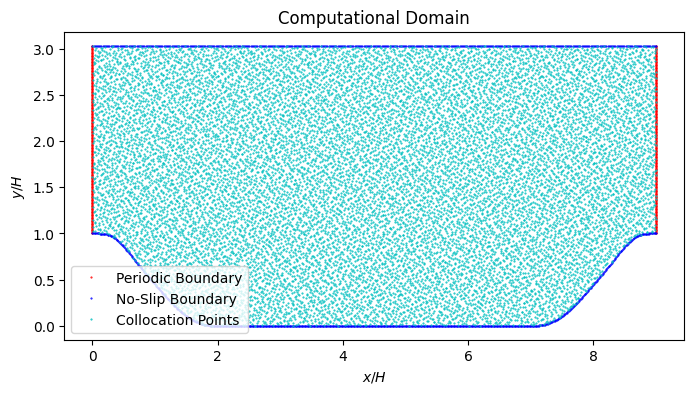

In [6]:
plt.figure(figsize=(8,4))
plt.plot(xy_inlet[:,0],xy_inlet[:,1],'.',color='r',markersize=1, label='Periodic Boundary')
plt.plot(xy_outlet[:,0],xy_outlet[:,1],'.',color='r',markersize=1)
plt.plot(xy_wall_top[:,0],xy_wall_top[:,1],'.',color='b',markersize=1, label='No-Slip Boundary')
plt.plot(xy_wall_hill[:,0],xy_wall_hill[:,1],'.',color='b',markersize=1)
plt.plot(xy_colloc[:,0],xy_colloc[:,1],'.',color='c',markersize=1, label='Collocation Points')
plt.ylabel('$y/H$')
plt.xlabel('$x/H$')
plt.title('Computational Domain')
plt.legend()

#### 2.1.2 Generation of Sparse Observational Data

We first import the DNS dataset used to emulate sparse readings from sensors and as a reference to evaluate the PINN performance:

In [7]:
def del_points_out_domain(data):

    #Deletes datapoints from DNS data that exist out of the domain
    index_in_domain = is_inside_domain(data['x'], data['y'])
    df = data[index_in_domain]
    df.reset_index(drop=True, inplace=True)
    return df

In [8]:
dns_data = np.loadtxt('alph10-9-3036.dat', skiprows=20)
dns_data = pd.DataFrame(dns_data, columns = ["x","y","u_mean","v_mean","w_mean","p_mean","dissipation_mean","vorticity_mean",\
                                "uu","vv","ww","uv","uw","vw","pp"])
dns_data = del_points_out_domain(dns_data) # Remove any points that are outside the computational domain
dns_data.describe()

,x,y,u_mean,v_mean,w_mean,p_mean,dissipation_mean,vorticity_mean,uu,vv,ww,uv,uw,vw,pp
count,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000,271071.000000
mean,4.495933,1.616318,0.696329,-0.000005,-0.001324,-0.005888,0.007553,4.463660,0.034314,0.018857,0.024382,-0.009332,0.000032,-0.000020,0.001977
std,2.445296,0.908422,0.367301,0.059956,0.001760,0.086515,0.013775,2.677147,0.020428,0.012672,0.015099,0.009486,0.000323,0.000183,0.001945
min,0.000000,0.000000,-0.241968,-0.100308,-0.010371,-0.367515,0.000000,0.000000,0.000000,0.000000,0.000000,-0.040315,-0.001198,-0.000742,0.000000
25%,2.425781,0.812656,0.410934,-0.032911,-0.002359,-0.071972,0.002191,2.612891,0.017342,0.008084,0.010878,-0.015640,-0.000117,-0.000086,0.000440
50%,4.500000,1.668197,0.867266,-0.006500,-0.000939,0.002985,0.004925,3.935831,0.028714,0.016533,0.019444,-0.007275,0.000059,-0.000003,0.001385
75%,6.562500,2.444629,0.987900,0.017032,-0.000247,0.065507,0.008537,5.360709,0.046456,0.027853,0.035124,-0.001666,0.000191,0.000059,0.002739
max,8.988281,3.029776,1.097769,0.526340,0.004050,0.204352,1.372633,85.243997,0.111902,0.055953,0.103080,0.016588,0.001612,0.000609,0.012733


Now that we have imported the DNS case data for the mean velocity fields, we can set up the sparse observational data. We set up a grid of sparse points in the domain, with the distance between points: $\Delta L = 0.5m$. This emulates the measurements one would obtain from sensor data. An exercise to see how the size of the observational dataset corresponds to varying accuracy of the simulation may be to adjust these distances between points and see how the PINN accuracy varies with reference to the test data. We offset the sensor locations slightly from the boundaries, as sensors directly on the boundaries providing less information than points directly within the domain, compared to points with boundary conditions.

In [9]:
dx = 0.5
dy = 0.5
xy_sparse, observations_sparse = gen_sparse_grid(dx, dy, dns_data, dist_from_top=0.1, dist_from_inlet=0.1)

Let's visualise the domain with all input points:

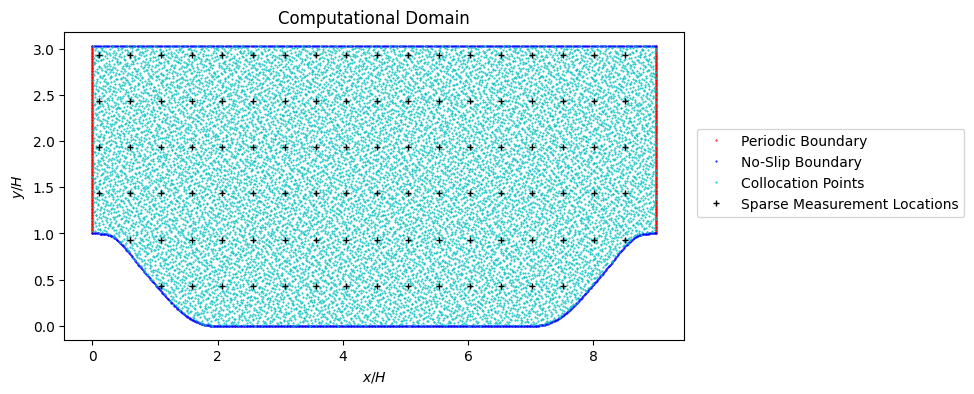

In [10]:
plt.figure(figsize=(8,4))
plt.plot(xy_inlet[:,0],xy_inlet[:,1],'.',color='r',markersize=1, label='Periodic Boundary')
plt.plot(xy_outlet[:,0],xy_outlet[:,1],'.',color='r',markersize=1)
plt.plot(xy_wall_top[:,0],xy_wall_top[:,1],'.',color='b',markersize=1, label='No-Slip Boundary')
plt.plot(xy_wall_hill[:,0],xy_wall_hill[:,1],'.',color='b',markersize=1)
plt.plot(xy_colloc[:,0],xy_colloc[:,1],'.',color='c',markersize=1, label='Collocation Points')
plt.plot(xy_sparse[:,0],xy_sparse[:,1],'+',color='k',markersize=5, label='Sparse Measurement Locations')
plt.ylabel('$y/H$')
plt.xlabel('$x/H$')
plt.title('Computational Domain')
plt.legend(loc=(1.02, 0.4))

# **ML Algorithm Code Snippet**

### 1.1 Neural Network and PINN Classes

### 1.1.1 Neural Network Class
We start by using PyTorch to create a neural network class to be trained using the generated points and the sparse measurement data.

For the ```init_param``` method, we initialise the weights and biases of the model with the aim that the variance of the output of each layer is the same at each layer. As the variance depends on the output of the number of inputs to the hidden layer for the variance of the outputs, while for the variance of the gradients this depends on the variance of the number of output layers\*. Aiming to keep the variance the same for both weights and gradients between layers as the model propagates prevents exploding or vanishing gradients, which can hurt training performance for methods that rely on these gradients. In this tutorial, we use Xavier initialisation in PyTorch; this is a standard choice for many PINNs using tanh activation functions. The tanh activation function is common due to its desirable features, such as being a $C^\infty$ function, unlike the ReLU activation function, which isn't continuously differentiable. This is preferable as, for the given governing equations where second-order derivatives are present, a $C^2$ activation function would be preferred. It is also zero-centred and is not strictly positive like the Sigmoid activation function. As such, it should be noted that some activation functions perform better with other initialisations, such as the ReLU activation function, where, in this tutorial, for the sake of exploring different activation functions in the hyperparameter tuning, it has been included. For this activation function, the He initialisation has been used.

[<sup>* X. Glorot and Y. Bengio. (2010). Understanding the difficulty of training deep feedforward neural networks, Proceedings of the Thirteenth International Conference on Artificial Intelligence and Statistics, PMLR 9:249-256.</sup>](https://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf)

In [11]:
class NeuralNetwork(nn.Module):
    
    def __init__(self, input_dim, output_dim, hidden_layer_dim, n_hidden_layers, activation = nn.Tanh(), init_seed=None):
        super(NeuralNetwork, self).__init__()

        # Set device
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        
        # Number of input dimensions (i.e. 2 for x,y)
        self.input_dim = input_dim

        # Number of output dimensions (i.e. 5 for U,V,P-Phi,f_u,f_v)
        self.output_dim = output_dim

        # Number of neurons ine each hidden layer
        self.hidden_layer_dim = hidden_layer_dim
        
        # Number of hidden layers
        self.n_hidden_layers = n_hidden_layers

        # Activation function for hidden layer
        self.activation = activation

        # Seed for reproducibility
        self.init_seed = init_seed
        
        # Build model
        self.input_layer = nn.Linear(self.input_dim, self.hidden_layer_dim)
        if self.n_hidden_layers > 1:
            hidden_units = [
                nn.Sequential(
                    nn.Linear(self.hidden_layer_dim, self.hidden_layer_dim),
                    self.activation
                )
                for _ in range(self.n_hidden_layers-1)
            ]
            self.hidden_layers = nn.Sequential(*hidden_units)
        self.output_layer = nn.Linear(self.hidden_layer_dim, self.output_dim)

        # Initialise model parameters and move model to device
        self.init_params()
        self.to(self.device)

        
    def forward(self, x):
        
        # Perform forward pass of model
        x = self.input_layer(x)
        x = self.activation(x)
        if self.n_hidden_layers > 1:
            x = self.hidden_layers(x)
        return self.output_layer(x)
    

    
    def init_params(self):
        
        # Initialises model weights and biases via Xavier uniform distribution

        if self.init_seed:
            torch.manual_seed(self.init_seed)

        # Determine gain for tanh function
        gain = nn.init.calculate_gain('tanh')
        
        # Xavier initialisation function for tanh
        def xavier_init(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=gain)
                m.bias.data.fill_(0.)
        
        # He initialisation function for tanh 
        def kaiming_init(m):
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
                m.bias.data.fill_(0.)

        #Initilise parameters
        if isinstance(self.activation, nn.Tanh):
            self.apply(xavier_init)
        elif isinstance(self.activation, nn.ReLU):
            self.apply(kaiming_init)

        return None

    def update_model(self):

        # Rebuilds model to update hyperparameters if they have been changed

        self.input_layer = nn.Linear(self.input_dim, self.hidden_layer_dim)
        if self.n_hidden_layers > 1:
            hidden_units = [
                nn.Sequential(
                    nn.Linear(self.hidden_layer_dim, self.hidden_layer_dim),
                    self.activation
                )
                for _ in range(self.n_hidden_layers-1)
            ]
            self.hidden_layers = nn.Sequential(*hidden_units)
        self.output_layer = nn.Linear(self.hidden_layer_dim, self.output_dim)

        # Initialize model parameters and move model to device
        self.init_params()
        self.to(self.device)
        
        return None

### 1.1.2 PINN Class

Here we will break down the PINN class into seperate chunks and explain each to get an understanding of how to create the PINN architecture using PyTorch.

##### Attributes
We first initialise attributes for the PINN class containing the PINN loss weights that balance the components for the losses, as well as any case specific parameters necessary to be used in the loss functions. We also initialise a parameter which acts as the body forcing term, which is also to be trained. Finally, we track the losses and number of iterations using attributes to plot any trace plots.

##### Physics Loss Method
We define a method that evaluates the sampled collocation points on the neural network, and then use autograd, PyTorch's automatic differentiation engine, to find the required partial derivatives with respect to the inputs. Once we have obtained these partial derivatives, we can find the residuals for each of the four governing equations:

$$
r_{1}(x, y) = \overline{U}_x + \overline{V}_y
$$
$$
r_{2}(x, y) = \overline{U}\overline{U}_x+ \overline{V}\overline{U}_y + \frac{1}{\rho}(\overline{P}-\phi)_x - \nu(\overline{U}_{xx} + \overline{U}_{yy}) - f_{us} + f_p
$$
$$
r_{3}(x, y) = \overline{U}\overline{V}_x+ \overline{V}\overline{V}_y + \frac{1}{\rho}(\overline{P}-\phi)_y - \nu(\overline{V}_{xx} + \overline{V}_{yy}) - f_{vs}
$$
$$
r_{4}(x, y) = (f_{us})_x +(f_{vs})_y
$$

We can then obtain the loss component:

$$
L_{PDE} = \frac{1}{N_{Colloc}} \sum_{i=1}^{N_{Colloc}} r_{1}(x_i, y_i)^2 + r_{2}(x_i, y_i)^2 + r_{3}(x_i, y_i)^2 + r_{4}(x_i, y_i)^2
$$

##### Data Loss Method

This loss is obtained via obtaining the mean squared error between the mean velocity of the observational data at sparse locations and the output of the PINN at these points:

$$
L_{Observed} = \frac{1}{N_{Observed}} \sum_{i=1}^{N_{Observed}} (U_i-\hat{U_i})^2 + (V_i-\hat{V_i})^2 
$$
Where $\hat{U_i}$ and $\hat{V_i}$ are the true mean velocities at the sparse measurement location $i$.

##### No-Slip Boundary Condition Loss Method
The outputs of the PINN at the no-slip data-points should have the mean velocity and solenoidal forcing outputs to be constrained to zero. This is implemented as a soft constraint by evaluating the PINN at the no-slip points, where the residual is then obtained:

$$
L_{NoSlip} = \frac{1}{N_{wall}} \sum_{i=1}^{N_{wall}} U_i^2 + V_i^2 +  f_{us_i}^2 + f_{vs_i}^2 
$$

##### Periodic Boundary Condition Loss Method
To impose the loss for the periodic boundary condition, we find the mean squared error between the output of the PINN at the inlet and the outlet points. We evaluate this at any points where the outlet and inlet share the same $y$-position; as such, there should be enough samples from the data where these positions are shared at both the inlet and the outlet:

$$
L_{Periodic} = \frac{1}{N_{Shared}} \sum_{i=1}^{N_{Shared}} (NN(0,y_i)-NN(9,y_i))^2
$$
Where $y_i\in N_{inlet}\cap N_{outlet}$ and $NN(x_i,y_i)$ are the outputs from the neural network.

##### Mass-Flow Boundary Condition Loss
To enforce the correct bulk flow at the crest, we impose another soft constraint for the correct bulk-velocity of 1 m/s, such that the Reynolds number is maintained at 5600:
$$
L_{Massflow} = {\rho}^2 (U_b-1)^2
$$
Where $U_b$ is the bulk-velocity at the crest (inlet) and $\rho = 1$ $kg/m^3$.

##### Total Loss Method

We can then return the total loss of the PINN:

$$
L = \lambda_{PDE}L_{PDE} + \lambda_{Observed}L_{Observed} + \lambda_{NoSlip}L_{NoSlip} + \lambda_{Periodic}L_{Periodic} + \lambda_{Massflow}L_{Massflow}
$$


In [12]:
class PINN:
    
    def __init__(self, NN, domain_height, optimizer = 'ADAM'):
        
        # Set device
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

        # Initialise lambda parameters used to balance loss terms for losses from
        # sparse points, physics losses, and boundary conditions.

        self.lambda_pde = 1
        self.lambda_data = 1
        self.lambda_wall = 1
        self.lambda_periodic = 1
        self.lambda_massflow = 1

        # Initialise Neural Network to Approximate Solution Fields
        self.NN = NN
        
        # Initialise Case parameters
        self.rho = 1.0 # Density
        self.Re = 5600 # Reynolds Number
        self.U = 1.0 # Inlet flow bulk velocity
        self.P = 0.0 # Pressure
        self.H = 1.0 # Crest height
        self.nu = self.U*self.H/self.Re # Kinematic viscosity
        
        self.fp = torch.nn.Parameter(torch.tensor(1., device=self.device), requires_grad=True).to(self.device) # Body forcing term
        self.Lin = torch.tensor(domain_height-1., device=self.device) # Inlet height

        # Lists for tracking losses over iterations
        self.pde_losses = []
        self.data_losses = []
        self.wall_losses = []
        self.periodic_losses = []
        self.massflow_losses = []
        self.losses = []

        # Initialise optimizer used for training and initialise variable for tracking number of iterations
        # training is ran over.
        self.optimizer = optimizer
    
    def reset_losses(self):
        
        # Reset all loss histories

        self.pde_losses = []
        self.data_losses = []
        self.wall_losses = []
        self.periodic_losses = []
        self.massflow_losses = []
        self.losses = []

    def mse(self, x, y):

        # Returns mean squared error

        return torch.mean((x - y) ** 2)
    
    def pde_residual(self, input):
        
        # Obtain PDE residual evaluated on collocation points
        input = input.clone().to(self.device)
        input.requires_grad = True # To obtain gradient wrt. inputs
        
        # Perform forward pass of neural network
        out = self.NN(input)
        
        # PINN outputs
        U, V, Pphi, fsu, fsv = [out[:, i:i+1] for i in range(5)]
        # Calculate gradients wrt. inputs via autograd
        U_grad = grad(U.sum(), input, create_graph=True)[0]
        V_grad = grad(V.sum(), input, create_graph=True)[0]
        Pphi_grad = grad(Pphi.sum(), input, create_graph=True)[0]
        fsu_grad = grad(fsu.sum(), input, create_graph=True)[0]
        fsv_grad = grad(fsv.sum(), input, create_graph=True)[0]
        # Index U gradient wrt. index 0 (x) and index 1 (y)
        U_x = U_grad[:,0].reshape(-1,1)
        U_y = U_grad[:,1].reshape(-1,1)
        
        # Index V gradient wrt. index 0 (x) and index 1 (y)
        V_x = V_grad[:,0].reshape(-1,1)
        V_y = V_grad[:,1].reshape(-1,1)

        # Index (P-Phi) gradient wrt. index 0 (x) and index 1 (y)
        Pphi_x = Pphi_grad[:,0].reshape(-1,1)
        Pphi_y = Pphi_grad[:,1].reshape(-1,1)
        
        # Index f_s,u gradient wrt. index 0 (x)
        # and index f_s,v gradient wrt. index 1 (y)
        fsu_x = fsu_grad[:,0].reshape(-1,1)
        fsv_y = fsv_grad[:,1].reshape(-1,1)
        
        # Obtain second derivative U_xx wrt. index 0 (x) via calling autograd on U_x 
        # and obtain second derivative U_yy wrt. index 1 (y) via calling autograd on U_y
        U_xx = grad(U_x.sum(), input, create_graph=True)[0][:,0].reshape(-1,1)
        U_yy = grad(U_y.sum(), input, create_graph=True)[0][:,1].reshape(-1,1)
        
        # Obtain second derivative V_xx wrt. index 0 (x) via calling autograd on V_x 
        # and obtain second derivative V_yy wrt. index 1 (y) via calling autograd on V_y
        V_xx = grad(V_x.sum(), input, create_graph=True)[0][:,0].reshape(-1,1)
        V_yy = grad(V_y.sum(), input, create_graph=True)[0][:,1].reshape(-1,1)
        
        # Compute residual for each of the governing equations defined
        continuity = U_x + V_y #Continuity equation
        x_momentum  = U*U_x + V*U_y + (1/self.rho)*Pphi_x - self.nu*(U_xx + U_yy) - fsu + self.fp # X-momentum equation, with f_p as a body forcing term
        y_momentum = U*V_x + V*V_y + (1/self.rho)*Pphi_y - self.nu*(V_xx + V_yy) - fsv # Y-momentum equation
        divfs = fsu_x + fsv_y # Equation obtained by decomposing forcing term into solenoidal component

        # Compute MSE for all governing equations to obtain requires loss
        zero_vector = torch.zeros_like(U, dtype=torch.float32)

        return self.mse(continuity, zero_vector) + self.mse(x_momentum, zero_vector) + self.mse(y_momentum, zero_vector) + self.mse(divfs, zero_vector)
    
    
    def data_loss(self, sparse_input, sparse_observations):
        
        # Supervised loss from sparse measurements
        
        # Perform forward pass of neural network
        out = self.NN(sparse_input)
        
        # PINN outputs
        U_pred = out[:,0].reshape(-1,1)
        V_pred = out[:,1].reshape(-1,1)
        
        # Sensor data
        U_true = sparse_observations[:,0].reshape(-1,1)
        V_true = sparse_observations[:,1].reshape(-1,1)

        return self.mse(U_pred, U_true) + self.mse(V_pred, V_true)
    
    def noslip_loss(self, input):
        
        # BC loss that enforces no-slip condition at walls
        
        # Perform forward pass of neural network
        out = self.NN(input)
        
        # PINN outputs
        U = out[:,0].reshape(-1,1)
        V = out[:,1].reshape(-1,1)
        fsu = out[:,3].reshape(-1,1)
        fsv = out[:,4].reshape(-1,1)

        # Compute MSE
        zero_vector = torch.zeros_like(U, dtype=torch.float32)

        return self.mse(U, zero_vector) + self.mse(V, zero_vector) + self.mse(fsu, zero_vector) + self.mse(fsv, zero_vector) 
        
    def periodic_loss(self, inlet_input, outlet_input):
        
        # BC loss that enforces output be the same in both inlet and outlet
        
        # Perform forward pass of neural network at both inlet and outlet
        inlet_out = self.NN(inlet_input)
        outlet_out = self.NN(outlet_input)

        # Compute MSE
        return self.mse(inlet_out, outlet_out)


    def massflow_loss(self, inlet_input):
        
        # Dirichlet BC loss to enforce mass flow of 1 at the inlet 
        
        # Perform forward pass of NN and store PINN outputs
        inlet_out = self.NN(inlet_input)
        U_in = inlet_out[:,0].reshape(-1,1)

        # Compute dy via uniformly spaced points at inlet to obtain mass flow at inlet
        dy = self.Lin/(inlet_input.shape[0])
        U_mean = torch.sum(dy*U_in)/(self.Lin)

        # Compute MSE
        return self.mse(U_mean, torch.tensor(1., device=self.device))

    def loss(self, xy_batched_colloc, xy_sparse, xy_sparse_labels, xy_wall, xy_inlet, xy_outlet):
        
        # Compute MSE for all losses
        mse_pde = self.pde_residual(xy_batched_colloc)
        mse_data = self.data_loss(xy_sparse, xy_sparse_labels)
        mse_wall = self.noslip_loss(xy_wall)
        mse_periodic = self.periodic_loss(xy_inlet, xy_outlet)
        mse_massflow  = self.massflow_loss(xy_inlet)

        # Append loss histories
        self.pde_losses.append(mse_pde.detach().item())
        self.data_losses.append(mse_data.detach().item())
        self.wall_losses.append(mse_wall.detach().item())
        self.periodic_losses.append(mse_periodic.detach().item())
        self.massflow_losses.append(mse_massflow.detach().item())
        
        # Compute overall loss of PINN via summation of each loss component with their respective weights
        loss = self.lambda_pde*mse_pde + self.lambda_data*mse_data + self.lambda_wall*mse_wall + self.lambda_periodic*mse_periodic + self.lambda_massflow*mse_massflow

        return loss


### 1.2 PINN Training and Hyperparameter Optimisation

### 1.2.1 PINN Training Functions

We now create a function to train the model according to the gradient-based optimisation scheme; in this case, we use both Adam* and limited memory BFGS (L-BFGS) as the two optimisation schemes. For our training scheme, we first minimise the loss function using mini-batched stochastic gradient descent under the Adam* scheme, this is to get to an initial accurate guess for the use of L-BFGS. Once this initial training run has finished, we run the more expensive L-BFGS optimisation scheme, which has better local convergence of gradient descent for the remaining iterations.

To train the model, gradients of the loss with respect to the parameters must be found. This is done via a similar approach to the gradients in the physics loss method in the PINN class, where automatic differentiation is used. In this case, the PyTorch method ```.backwards()``` is used to handle this instead of explicitly using the autograd engine from the PyTorch library. 

[<sup>* D. P. Kingma and J. Ba. (2015). Adam: A Method for Stochastic Optimization. International Conference on Learning Representations 2015.</sup>](https://arxiv.org/abs/1412.6980)

In [13]:
def fit_model(model, 
              xy_colloc, 
              xy_sparse, 
              xy_sparse_labels, 
              xy_wall_hill, 
              xy_wall_top, 
              xy_inlet, 
              xy_outlet, 
              optimizer, 
              num_epochs, 
              colloc_batch_size, 
              verbose = True, 
              print_epoch = 25):
    
    #Fit model for a single optimiser

    # Initialise collocation points evaluated via PDE residuals
    xy_colloc =  torch.tensor(xy_colloc).float().to(model.device)
        
    # Initialise sparse points
    xy_sparse =  torch.tensor(xy_sparse).float().to(model.device)
    xy_sparse_labels =  torch.tensor(xy_sparse_labels).float().to(model.device)

    # Initialise wall data points
    xy_wall = torch.tensor(np.vstack((xy_wall_hill,xy_wall_top))).float().to(model.device)

    # Initialise inlet and outlet points 
    xy_inlet =  torch.tensor(xy_inlet).float().to(model.device)
    xy_outlet =  torch.tensor(xy_outlet).float().to(model.device)
        
    # Initialise batches
    indices = torch.randperm(len(xy_colloc), device=model.device)
    colloc_batches = []
    
    for i in range(0, len(xy_colloc), colloc_batch_size):
        batch_idx = indices[i:i + colloc_batch_size]
        colloc_batches.append(xy_colloc[batch_idx])

    # Store number of iterations and epochs to track when to print losses
    model.optimizer_iterations = 0
    epoch = 0

    for epoch in range(num_epochs):
        
        epoch += 1 # Update epoch counter

        for colloc_batch in colloc_batches: # Obtain loss over batch
            
            def closure():

                model.optimizer_iterations += 1 # Update iteration counter
                optimizer.zero_grad() # Set to zero gradient to prevent gradient accumulation

                # Update gradients wrt. weights and biases via autograd
                loss = model.loss(colloc_batch, xy_sparse, xy_sparse_labels, xy_wall, xy_inlet, xy_outlet)

                if not np.isnan(loss.detach().item()):
                    loss.backward()

                model.losses.append(loss.detach().item())
                # Print loss statistics at iteration if using LBFGS
                if verbose and model.optimizer == 'LBFGS' and model.optimizer_iterations%(print_epoch*10)==0:
                    
                    print_loss_stats(model, epoch, model.optimizer_iterations, is_adam=False, is_lbfgs=True) # Print losses
                
                return loss
            
            optimizer.step(closure=closure)

        # Print loss statistics at epoch if using ADAM
        if verbose and epoch%print_epoch==0:

            print_loss_stats(model, epoch, model.optimizer_iterations, is_adam=True, is_lbfgs=False) # Print losses

    if verbose:
        # Print final loss
        print(f'Final Loss (Log10): {round(np.log10(model.losses[-1]).item(), 4)}')

    return model.optimizer_iterations

We can then create a function that combines the two training runs for Adam and L-BFGS, and obtain the time per iteration for each of the two optimisation schemes:

In [14]:
def train(model, 
          xy_colloc, 
          xy_sparse, 
          xy_sparse_labels, 
          xy_wall_hill, 
          xy_wall_top, 
          xy_inlet,
          xy_outlet, 
          adam_epochs, 
          adam_lr, 
          lbfgs_max_iterations, 
          adam_batch_size = 2500,
          print_time_per_iter = True, 
          verbose = True, 
          print_epoch = 25):
    
    # Perform training run with both ADAM and LBFGS optimizers, returning time per iteration
    
    #Define ADAM optimiser and L-BFGS optimiser parameters
    optimizer_LBFGS = torch.optim.LBFGS(list(model.NN.parameters())+[model.fp],
                                    max_iter=lbfgs_max_iterations,
                                    line_search_fn="strong_wolfe",
                                    tolerance_change=1.0*np.finfo(float).eps,
                                    tolerance_grad=1.0*np.finfo(float).eps)

    optimizer_ADAM = torch.optim.Adam(list(model.NN.parameters())+[model.fp], lr=float(adam_lr))

    # Set model batch size and optimizer for 
    # use with mini-batch SGD with ADAM
    model.colloc_batch_size = adam_batch_size
    model.optimizer = 'ADAM'
    
    # Start optimisation under ADAM and start timer to measure performance
    start_time = time.time()
    ADAM_iterations = fit_model(model, xy_colloc, xy_sparse, xy_sparse_labels, xy_wall_hill, 
                                xy_wall_top, xy_inlet, xy_outlet, optimizer_ADAM, adam_epochs, 
                                adam_batch_size, verbose = verbose, print_epoch = print_epoch)

    elapsed_time = time.time() - start_time
    
    # Measure time per iteration for ADAM
    time_per_iter_ADAM =  elapsed_time/ADAM_iterations
    
    # Use all datapoints instead of batch for LBFGS 
    model.colloc_batch_size = xy_colloc.shape[0]
    model.optimizer = 'LBFGS'

    # Start optimisation under L-BFGS and start timer to measure performance
    start_time = time.time()
    LBFGS_iterations = fit_model(model, xy_colloc, xy_sparse, xy_sparse_labels, xy_wall_hill,
                                 xy_wall_top, xy_inlet, xy_outlet, optimizer_LBFGS, 1,
                                  xy_colloc.shape[0], verbose = verbose, print_epoch = print_epoch) #Full batch for LBFGS
    
    elapsed_time = time.time() - start_time
    
    # Measure time per iteration for L-BFGS
    time_per_iter_LBFGS =  elapsed_time/LBFGS_iterations
    if print_time_per_iter:
        print(f'Time per batched ADAM iteration: {round(time_per_iter_ADAM, 4)} seconds/iter')
        print(f'Time per L-BFGS iteration: {round(time_per_iter_LBFGS, 4)} seconds/iter')

    return None

### 1.2.2 PINN Loss Weights

PINN loss weights define the overall loss, and consequently, the constraints on the solution from the PINN. Choosing weights too small for the physics loss compared to the other components causes the gradients in the physics loss to be too small, causing unphysical solutions. However, if the physics weight is too large, the unique solution provided by observational data and boundary conditions may not be learned. Due to this, the loss weights are an important factor for the performance of PINNs, and care should be taken in the choice of these weights, whether this be through a hyperparameter search or through some other choice, such as an adaptive weighting scheme.

### 1.2.3 Hyperparameter Optimisation Functions

For this tutorial, a simplifed hyperparameter optimisation scheme has been implemented. To tune the hyperparameters, a grid search is used to obtain the correct weights for the loss components, the neural network hyperparameters (model depth and activation functions) and the learning rate for the Adam optimisation scheme. Other black-box optimisation schemes can be used for this tuning to help aid the increasing dimensionality of the search problem. To reduce computational demand, hyperparameter tuning is performed with fewer Adam epochs and L-BFGS iterations than in the actual training run; in this case, training was performed with 100 Adam epochs and 250 L-BFGS iterations.

To reduce the computational demand of this search, we split this into two searches: the first, for the weights that balance the loss components and the second, for neural network hyperparameters and Adam learning rate. In the first search, we only consider three hyperparameters: the weight for the observed data, the weight for the boundary conditions at the walls, and the weight for the boundary and initial conditions at the inlet/outlet. The weight for the physics loss is kept fixed at 1. For the second search, we tune the model depth and activation functions while fixing the number of neurons in the hidden layer at 50. Given the use of Wolfe conditions for L-BFGS, we only tune the learning rate for the Adam optimisation scheme

Only three weights were chosen to tune for the loss components to reduce computational expense, but more weights can be used to achieve finer control for the solution obtain via the PINN (i.e. a weight that controls only the U-velocity loss at the wall).

In [15]:
def grid_search_weights(validation_input, 
                        validation_labels, 
                        model, 
                        xy_colloc, 
                        xy_sparse, 
                        xy_sparse_labels, 
                        xy_wall_hill, 
                        xy_wall_top, 
                        xy_inlet, 
                        xy_outlet, 
                        adam_lr=1e-3, 
                        adam_epochs=100, 
                        adam_batch_size=2500,
                        lbfgs_iter = 250,
                        data_weight = [1,10],
                        wall_weight = [0.1,1,10],
                        inlet_weight=[0.1,1,10]):
      
      # Create grid of all possible combination of hyperparameters
      grid = np.meshgrid(data_weight,wall_weight,inlet_weight)
      weights = np.hstack((grid[0].reshape(-1,1),grid[1].reshape(-1,1),grid[2].reshape(-1,1)))
      mse = torch.nn.MSELoss() #MSE loss for to obtain L2 loss 

      # Initialise validation inputs and labels to tensors
      validation_input = torch.tensor(validation_input).float().to(model.device)
      validation_labels = torch.tensor(validation_labels).float().cpu()

      # Store loss history
      l2_losses = []

      for i in range(weights.shape[0]):
            
            model.NN.update_model() # Re-initialise parameters

            # Set PINN loss weights
            model.lambda_pde = 1.
            model.lambda_data = weights[i,0]
            model.lambda_wall = weights[i,1]
            model.lambda_periodic = weights[i,2]
            model.lambda_massflow = weights[i,2]


            # Train model on reduced iterations
            train(model, xy_colloc, xy_sparse, xy_sparse_labels, xy_wall_hill, xy_wall_top,
                  xy_inlet, xy_outlet, adam_epochs, adam_lr, lbfgs_iter, adam_batch_size=adam_batch_size,
                  print_time_per_iter = False, verbose = False)


            # Forward pass of model
            with torch.no_grad():
                  val_output =  model.NN(validation_input)
            
            # Extract quantities of interest
            approx_fields  = val_output[:,0:2].cpu().detach()

            # Append loss to history
            l2_losses.append(mse(approx_fields, validation_labels))

            print(f'{i+1}/{weights.shape[0]} PDE weight: 1.0, data weight: {weights[i,0]},',
                  f'BC (Wall) weight: {weights[i,1]}, BC (Inlet/Outlet) weight: {weights[i,2]},',
                  f'L2 Validation Loss: {l2_losses[-1]}')

      # Find minimum l2 loss and index for which it occurs
      index_min = np.argmin(l2_losses)

      # Reset loss histories and set model hyperparameters to ones that achieved best empirical loss
      model.reset_losses()
      model.NN.update_model()
      model.lambda_pde = 1.
      model.lambda_data = weights[index_min,0]
      model.lambda_wall = weights[index_min,1]
      model.lambda_periodic = weights[index_min,1]
      model.lambda_massflow = weights[index_min,1]

      print(f'Minimum L2 Loss: {l2_losses[index_min]}, at PDE weight: 1.0, data weight {weights[index_min,0]},',
            f'BC (Wall) weight {weights[index_min,1]}, BC (Inlet/Outlet) weight: {weights[index_min,2]}')

      return None

def grid_search_NN_hyperparameters(validation_input, 
                                   validation_labels, 
                                   model, 
                                   xy_colloc, 
                                   xy_sparse, 
                                   xy_sparse_labels, 
                                   xy_wall_hill, 
                                   xy_wall_top, 
                                   xy_inlet, 
                                   xy_outlet, 
                                   adam_epochs=100, 
                                   adam_batch_size=2500, 
                                   lbfgs_iter = 250, 
                                   lr = [1e-2,1e-3,1e-4],
                                   NN_depth = [3,5,7],
                                   activation = [nn.Tanh(),nn.ReLU()]):

    # Create grid of all possible combination of hyperparameters
    grid = np.meshgrid(lr,NN_depth,activation)
    hyperparameters = np.hstack((grid[0].reshape(-1,1),grid[1].reshape(-1,1),grid[2].reshape(-1,1)))
    mse = torch.nn.MSELoss() #MSE loss for to obtain L2 loss
    
    # Initialise validation input to tensor
    validation_input = torch.tensor(validation_input).float().to(model.device)
    validation_labels = torch.tensor(validation_labels).float().cpu()

    # Store loss history
    l2_losses = []

    for i in range(hyperparameters.shape[0]):

      # Set NN hyperparameters and ADAM lr
      adam_lr = hyperparameters[i,0]
      model.NN.n_hidden_layers = hyperparameters[i,1]
      model.NN.activation = hyperparameters[i,2]
      model.NN.update_model()

        # Train model using LR of iteration and smaller number of L-BFGS iterations 
      train(model, xy_colloc, xy_sparse, xy_sparse_labels, xy_wall_hill, xy_wall_top,
            xy_inlet, xy_outlet, adam_epochs, adam_lr, lbfgs_iter, adam_batch_size=adam_batch_size,
            print_time_per_iter = False, verbose = False)


      # Forward pass of model
      with torch.no_grad():
            val_output =  model.NN(validation_input)
      
      # Extract quantities of interest
      approx_fields  = val_output[:,0:2].cpu().detach()
      
      # Append loss to history
      l2_losses.append(mse(approx_fields, validation_labels))

      print(f'{i+1}/{hyperparameters.shape[0]} LR: {hyperparameters[i,0]}, NN Depth: {hyperparameters[i,1]},',
            f'Hidden Layer Activation Function: {hyperparameters[i,2]}, L2 Validation Loss: {l2_losses[-1]}')

    # Find minimum l2 loss and index for which it occurs
    index_min = np.argmin(l2_losses)

    # Reset losses and set model hyperparameters to ones that achieved best empirical loss
    model.reset_losses()
    model.NN.n_hidden_layers = hyperparameters[index_min,1]
    model.NN.activation = hyperparameters[index_min,2]
    model.NN.update_model()

    tuned_adam_lr = hyperparameters[index_min,0]

    print(f'Minimum L2 Loss: {l2_losses[index_min]}, at LR: {hyperparameters[index_min,0]},',
          f'NN Depth: {hyperparameters[index_min,1]}, Hidden Layer Activation Function: {hyperparameters[index_min,2]}')

    return tuned_adam_lr

### 1.2.4 Validation Training Data

To perform this tuning, we create an unseen validation set to measure the performance of the hyperparameters, and we perform an 80/20 split between training and validation data. Once hyperparameter tuning was completed, the PINN was trained on the entire set of measured data.

Given the small size of the measured data, it is worth considering K-fold cross-validation to obtain a better estimate of the validation loss, requiring K times more training runs, increasing the computational cost. This was not performed in the tutorial, but it may improve the hyperparameter search on unseen data due to a better estimate of the validation loss.

In [16]:
torch.manual_seed(0)
indices = torch.randperm(len(xy_sparse))
val_len = int(0.2*len(xy_sparse))
val_indices  = indices[0:val_len]
train_indices = indices[val_len:]
xy_sparse_validation_inputs = xy_sparse[val_indices]
xy_sparse_validation_inputs_observations = observations_sparse[val_indices]
xy_sparse_train_inputs = xy_sparse[train_indices]
xy_sparse_train_observations = observations_sparse[train_indices]

Let's visualise the training and validation data on the computational domain:

Text(0.5, 1.0, 'Training and Validation Sparse Measurements for Hyperparameter Tuning')

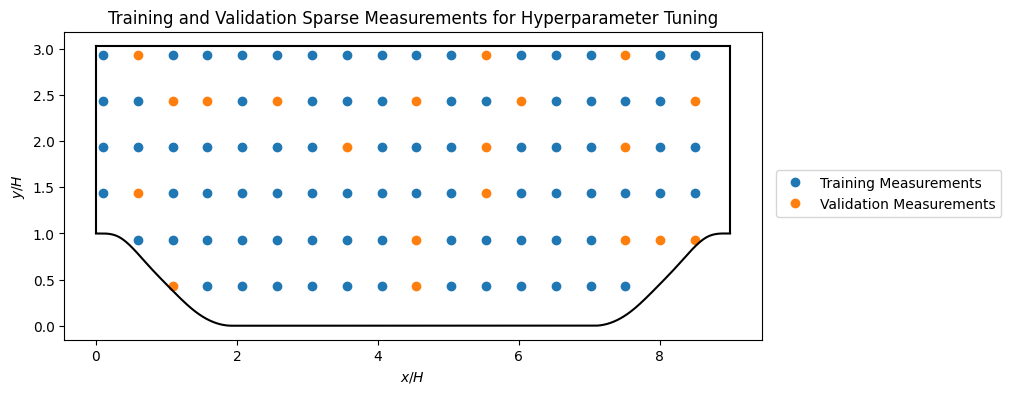

In [17]:
plt.figure(figsize=(9,4))
plt.plot(xy_sparse_train_inputs[:,0], xy_sparse_train_inputs[:,1], 'o', label='Training Measurements')
plt.plot(xy_sparse_validation_inputs[:,0], xy_sparse_validation_inputs[:,1], 'o', label='Validation Measurements')
plt.xlabel('$x/H$')
plt.ylabel('$y/H$')
plt.legend(loc=(1.02, 0.4))
plot_computational_domain()
plt.title('Training and Validation Sparse Measurements for Hyperparameter Tuning')

### 1.2.5 Hyperparameter Optimisation
We now initialise a neural network and the PINN model and perform our grid searches:

In [18]:
NN = NeuralNetwork(input_dim=2,output_dim=5,hidden_layer_dim=50,n_hidden_layers=5,activation=nn.Tanh())

PINN_model = PINN(NN, domain_height)

grid_search_weights(xy_sparse_validation_inputs,
                     xy_sparse_validation_inputs_observations, 
                     PINN_model, 
                     xy_colloc, 
                     xy_sparse_train_inputs, 
                     xy_sparse_train_observations, 
                     xy_wall_hill,
                     xy_wall_top, 
                     xy_inlet, 
                     xy_outlet)

adam_lr = grid_search_NN_hyperparameters(xy_sparse_validation_inputs,  
                                         xy_sparse_validation_inputs_observations, 
                                         PINN_model, 
                                         xy_colloc, 
                                         xy_sparse_train_inputs, 
                                         xy_sparse_train_observations,
                                         xy_wall_hill,
                                         xy_wall_top,
                                         xy_inlet,
                                         xy_outlet)

1/18 PDE weight: 1.0, data weight: 1.0, BC (Wall) weight: 0.1, BC (Inlet/Outlet) weight: 0.1, L2 Validation Loss: 0.007060459814965725
2/18 PDE weight: 1.0, data weight: 1.0, BC (Wall) weight: 0.1, BC (Inlet/Outlet) weight: 1.0, L2 Validation Loss: 0.007529380731284618
3/18 PDE weight: 1.0, data weight: 1.0, BC (Wall) weight: 0.1, BC (Inlet/Outlet) weight: 10.0, L2 Validation Loss: 0.00762310391291976
4/18 PDE weight: 1.0, data weight: 10.0, BC (Wall) weight: 0.1, BC (Inlet/Outlet) weight: 0.1, L2 Validation Loss: 0.0030936819966882467
5/18 PDE weight: 1.0, data weight: 10.0, BC (Wall) weight: 0.1, BC (Inlet/Outlet) weight: 1.0, L2 Validation Loss: 0.0037217922508716583
6/18 PDE weight: 1.0, data weight: 10.0, BC (Wall) weight: 0.1, BC (Inlet/Outlet) weight: 10.0, L2 Validation Loss: 0.0047649964690208435
7/18 PDE weight: 1.0, data weight: 1.0, BC (Wall) weight: 1.0, BC (Inlet/Outlet) weight: 0.1, L2 Validation Loss: 0.014750520698726177
8/18 PDE weight: 1.0, data weight: 1.0, BC (Wall

### 1.2.6 PINN Training

We then perform training using 1000 epochs with the Adam optimiser and then train with 15,000 iterations of the L-BFGS optimiser with the entire set of sparse measurements (in practice, the number of iterations of both schemes is significantly higher for sufficient minimisation of the loss function):

Note: If training on a CPU or with reduced compute capabilities, it may be worth reducing the number of epochs used while training with Adam, and the number of iterations used while training with L-BFGS. As a suggestion, one should limit the reduction to 250-500 epochs of Adam and 5000 iterations of L-BFGS to prevent larger magnitude errors.

In [19]:
adam_epochs = 1000
lbfgs_iter = 15000

train(PINN_model, xy_colloc, xy_sparse, observations_sparse, xy_wall_hill, xy_wall_top, xy_inlet, xy_outlet, adam_epochs, adam_lr, lbfgs_iter)

ADAM Epoch: 25, Total Loss (Log10):  -0.7564
PDE Loss (Log10): -1.7628, Data Loss (Log10): -1.9534, Wall Loss (Log10): -0.3495, Periodic Inlet/Outlet BC Loss (Log10): -1.7509, Mass Flow Inlet BC Loss (Log10): -2.8493
ADAM Epoch: 50, Total Loss (Log10):  -1.0256
PDE Loss (Log10): -1.956, Data Loss (Log10): -2.3526, Wall Loss (Log10): -0.4285, Periodic Inlet/Outlet BC Loss (Log10): -1.8476, Mass Flow Inlet BC Loss (Log10): -2.9846
ADAM Epoch: 75, Total Loss (Log10):  -1.1341
PDE Loss (Log10): -2.1098, Data Loss (Log10): -2.5204, Wall Loss (Log10): -0.4629, Periodic Inlet/Outlet BC Loss (Log10): -2.0143, Mass Flow Inlet BC Loss (Log10): -3.0848
ADAM Epoch: 100, Total Loss (Log10):  -1.1821
PDE Loss (Log10): -2.2621, Data Loss (Log10): -2.5816, Wall Loss (Log10): -0.4772, Periodic Inlet/Outlet BC Loss (Log10): -2.1742, Mass Flow Inlet BC Loss (Log10): -3.0812
ADAM Epoch: 125, Total Loss (Log10):  -1.2118
PDE Loss (Log10): -2.3741, Data Loss (Log10): -2.6248, Wall Loss (Log10): -0.4841, Per

Let's plot the loss trace to visualise the loss terms throughout training:

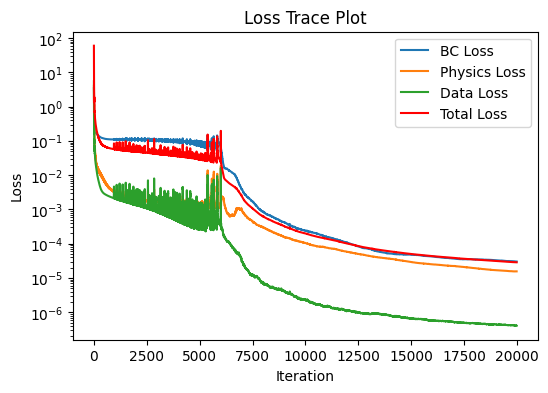

In [20]:
#Plot loss trace plot including all loss terms
plt.figure(figsize=(6,4))
plt.semilogy(np.arange(1,len(PINN_model.data_losses)+1), np.mean(np.array([PINN_model.periodic_losses,PINN_model.wall_losses,PINN_model.massflow_losses]),axis=0), label='BC Loss')
plt.semilogy(np.arange(1,len(PINN_model.pde_losses)+1),PINN_model.pde_losses, label='Physics Loss')
plt.semilogy(np.arange(1,len(PINN_model.data_losses)+1),PINN_model.data_losses, label='Data Loss')
plt.semilogy(np.arange(1,len(PINN_model.losses)+1),PINN_model.losses,color='r', label='Total Loss')
plt.title('Loss Trace Plot')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

# **Results and Postprocessing**

### 1.1 Inference Data and L2 Error

To compare the results to the DNS validation data, we first create an input dataset for the PINN. To do this, we create a dataset of the $x$, $y$ pairs of every point of the DNS solution and perform a forward pass of the PINN using this dataset. We can then compare the two mean-velocity field solutions:

In [21]:
# Evaluate Test-Inputs on PINN
test_input = torch.tensor(dns_data[['x','y']].to_numpy()).float().to(PINN_model.device)
test_target = torch.tensor(dns_data[['u_mean','v_mean']].to_numpy()).float().to(PINN_model.device)

# Without storing variables for calculating gradient
with torch.no_grad():
    test_output =  PINN_model.NN(test_input)

# Index only PINN mean velocity fields
U_approx  = test_output[:,0].cpu().detach()
V_approx  = test_output[:,1].cpu().detach()

# Index exact DNS mean velocity fields
U_exact  = test_target[:,0].cpu().detach()
V_exact  = test_target[:,1].cpu().detach()


X = test_input[:,0].cpu().detach()
Y = test_input[:,1].cpu().detach()

print(f'Mean L2 error for Mean Velocity U: {float(torch.mean((U_exact - U_approx)**2))}')
print(f'Mean L2 error for Mean Velocity V: {float(torch.mean((V_exact - V_approx)**2))}')

Mean L2 error for Mean Velocity U: 0.0009149799589067698
Mean L2 error for Mean Velocity V: 9.873614544630982e-06


### 1.2 Flow-field Visualisations

Let's visualise the velocity flow fields and compare the L2 error between the two solutions:

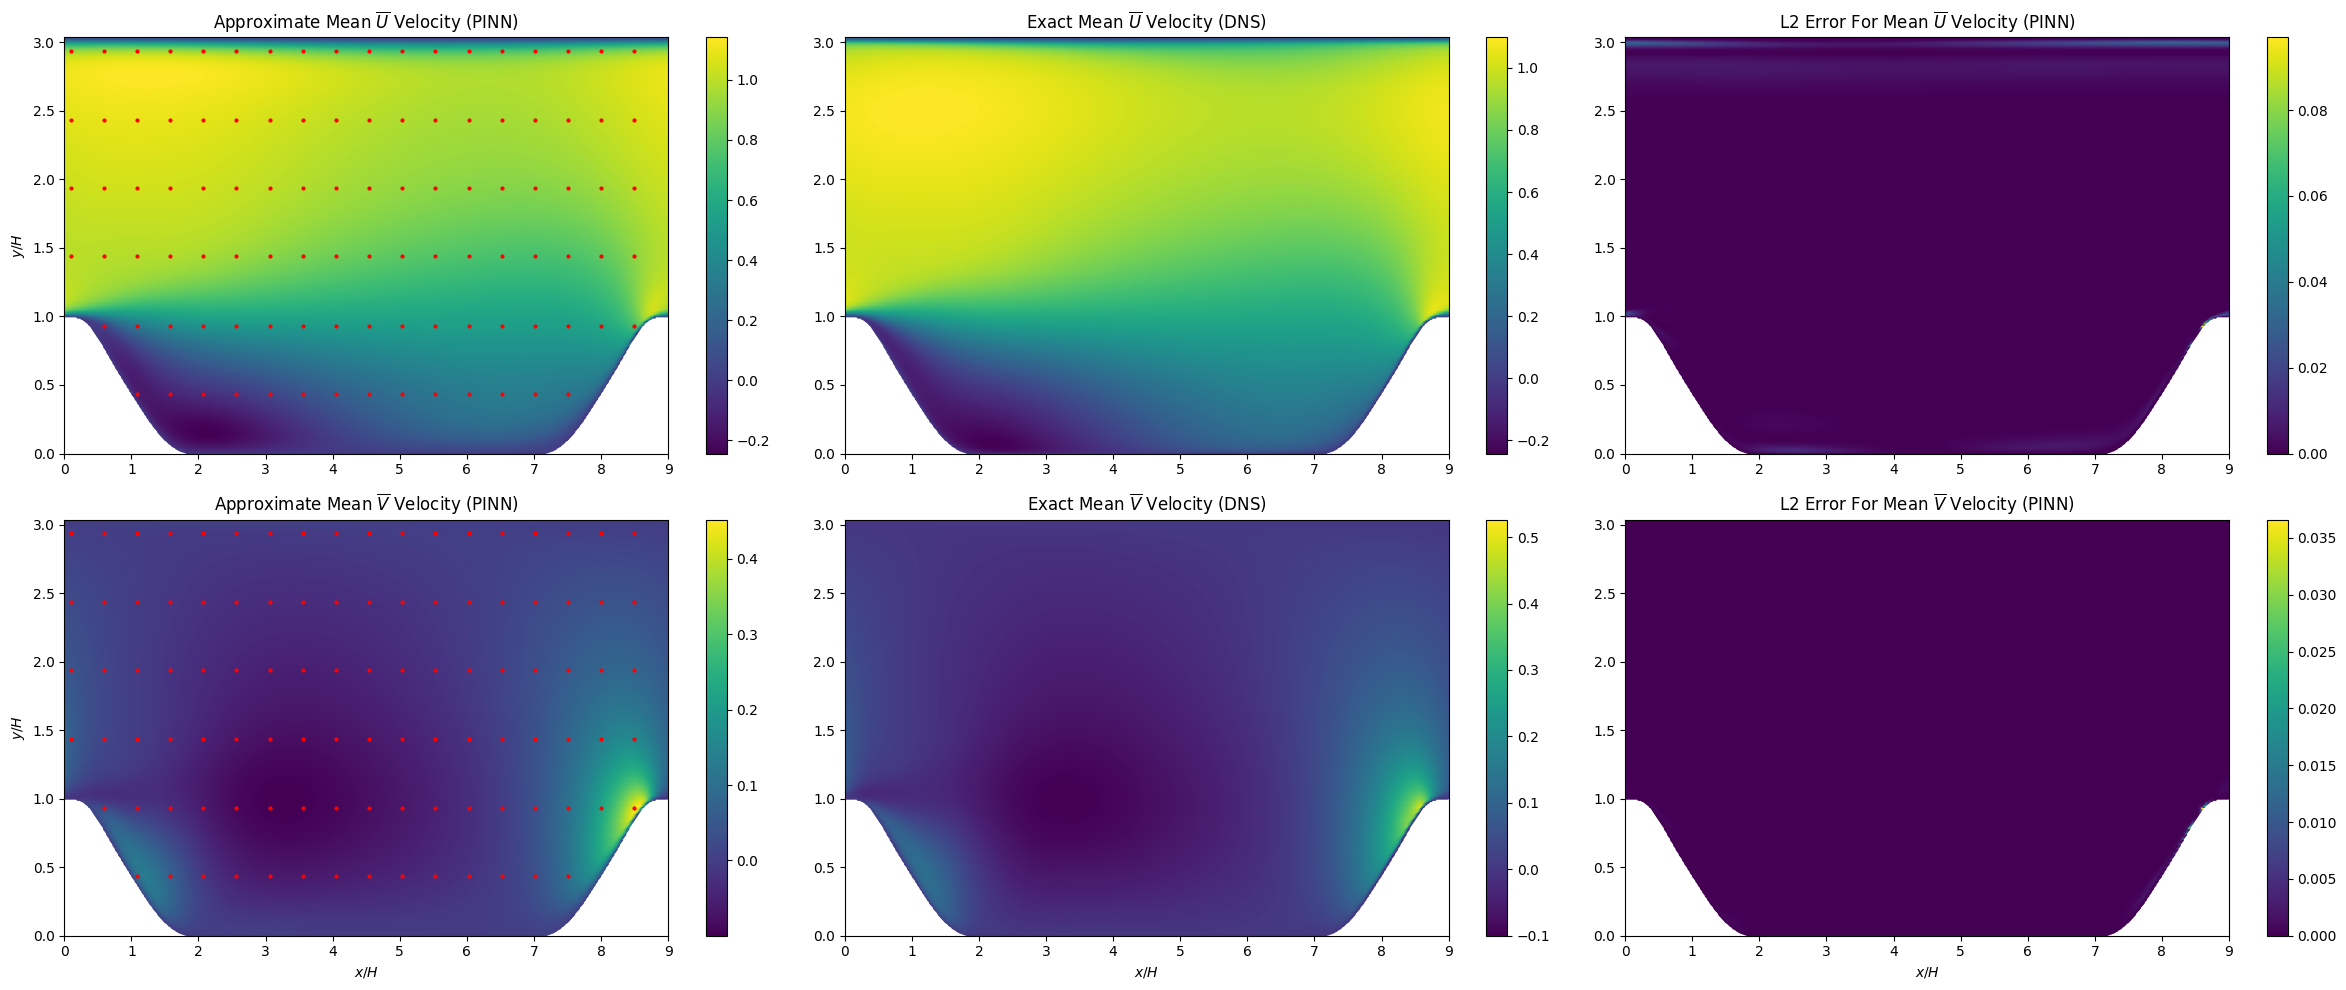

In [22]:
compare_flow_fields(X, Y, U_approx, U_exact, V_approx, V_exact, xy_sparse)

We can then plot the streamwise velocity profiles at different positions on the computational domain and plot the streamline that divides the recirculation region on the domain with reference to the DNS solution in black:

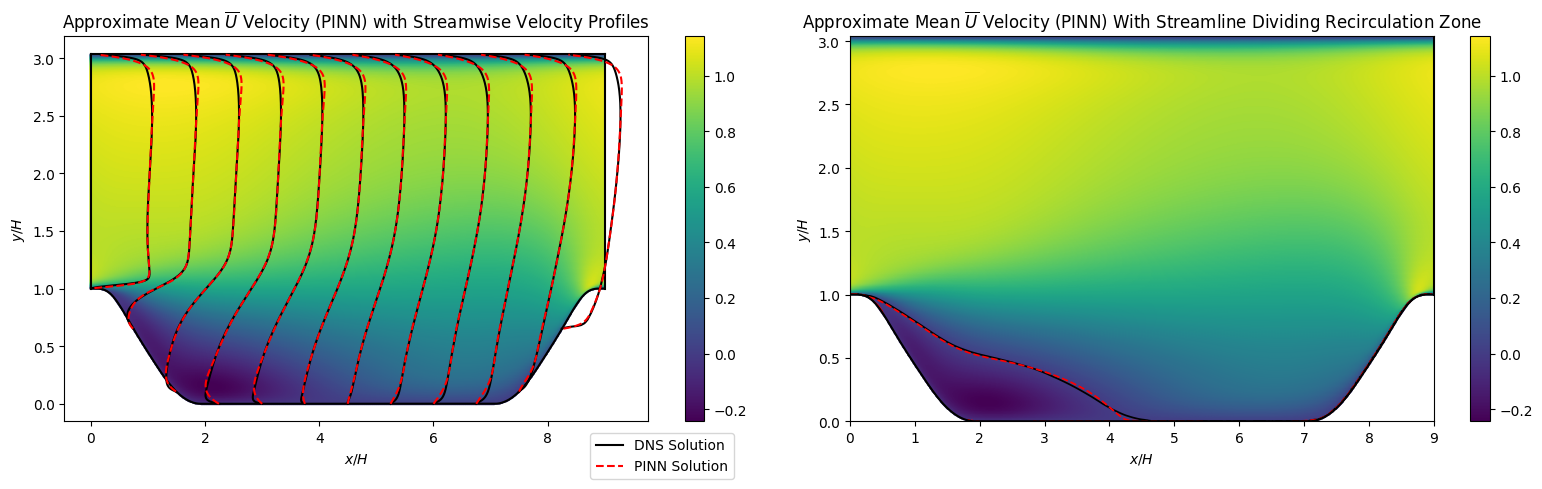

In [23]:
plot_streamlines(X, Y, U_approx, U_exact)

### 1.3 Discussion

The highest magnitude errors can be seen at the most sensitive regions near the walls; some considerations that can be tested to decrease the error at these locations are:

- Sensor placement: try to adjust sensor placement to increase the number of sensors in sensitive regions.
- Training iterations/epochs: try increasing the number of iterations of L-BFGS and the number of epochs of Adam.
- PINN capacity: the number of layers or size of layers may not be enough to fully represent the solution field.
- Training data: try adjusting the number of unsupervised collocation points, as they may not be dense enough in sensitive regions.

# **Troubleshooting**
### 1.1 Approaches to Troubleshooting
Some approaches to troubleshooting are described below:

- Keeping a small holdout set prior to the final training run can aid in checking the correct behaviour of the PINN solution.
- Printing components of the different losses during training can help with troubleshooting. It can help by:

    - Identifying any issues with individual loss functions.
    - Identifying any conflicting losses which may need more rigorous tuning to constrain the PINN to the correct solution.
    - Tracking the stability of training.

### 1.2 Common Problems

Some common problems and some ways to mitigate these problems you may run into are described below:

- Inconsistent validation loss on an unseen test set, sources of these errors can be from:

    - Incorrectly defined loss functions for the boundary/initial conditions, observational data, or physics loss.
    - Issues stemming from the weighting of different loss components, where more rigorous tuning may be required.
    - The spacing between sparse observational data may not provide enough detail to reconstruct the flow, where a larger amount of data may be necessary.


- Inconsistent tensor shapes, causing mismatch errors or may be automatically broadcast to an incorrect shape during element-wise operations.

    - Consistent checking of tensor shape and reshaping to correct this can help prevent these errors from occurring.


- The model and data are not on consistent devices before training.

    - Ensure the model and data are sent to the correct device.


- Inconsistent data types between different data, such as float32 and float64.

    - If problems occur, manually defining datatypes while initialising tensors can prevent this.

    

# **Overall Performance**

Overall, it can be seen that the PINN reconstructs the mean flow successfully, while taking advantage of being a mesh-free method, making the ease of implementation easier. It should be noted that the computational cost required for the optimisation is greater than traditional variational approaches $[1]$, $[2]$. Furthermore, hyperparameter optimisation also increases the computational cost, requiring repeated training runs to obtain a set of tuned hyperparameters. A detailed discussion of the computational is provided below.

### 1. Training Cost

When compared to the variational approach, experiments conducted by Patel et al. $[2]$ for the same case showed that while optimisation iterations are significantly cheaper per iteration in the PINN approach, being on average 65x faster, the PINN required significantly more iterations to converge to the solution. The variational approach converged before 100 iterations, while the PINN required up to $5$ x $10^5$ iterations. This shows that the computational cost exceeds the variational approach by orders of magnitude due to the large number of iterations required to train the model.

### 2. Hyperparameter Tuning Cost

Given the importance of many hyperparameters on the performance of a PINN, such as loss weights, neural network hyperparameters and optimisation hyperparameters, these must all be tuned. This results in a lengthy search process where training runs are repeated. This results in a rather large parameter space due to the increased complexity of loss component weights that must also be tuned. Furthermore, if the resulting validation dataset is small, k-fold cross-validation may be considered, which will require k extra training runs. As such, it is clear that the hyperparameter optimisation has a significant impact on computational cost.

### 3. CPU vs GPU

It's also important to note that the computational cost can be reduced significantly by using a GPU instead of a CPU. This is due to the lack of dependence on other points within the domain, since only a pointwise derivative is needed and can be obtained explicitly through the automatic differentiation engine. This allows PINN training to be sped up on GPUs by leveraging the parallelism that accelerates the matrix calculations required for forward and backward passes.

# **Extensions**
### 1. Turbulence Model Augmentation
- Work from Patel et al. $[2]$ has shown this methodology can be applied to RANS equations while utilising traditional turbulence models that approximate the Reynolds stresses for closure. PINNs with sparse data obtain a solution to the unclosed part of this new set of governing equations, improving the accuracy of the flow fields.
### 2. Hyperparameter Tuning
- Black-box optimisation for the tuning of hyperparameters tends to be more efficient than simple grid search methods. Black-box optimisation techniques such as Bayesian optimisation should be considered to reduce the computational cost required to effectively train PINNs.
- Adaptive weighting of PINN loss components can also be implemented to reduce the number of hyperparameters tuned $[4]$, $[5]$, $[6]$.
### 3. Adaptive Collocation Points
- Given a fixed budget of collocation points, to improve the accuracy of the solution obtained by a PINN, it may be beneficial to adaptively resample collocation points to sample areas with higher residual loss more often. Work from Wu et al. $[7]$ provides details on how to resample areas with higher residual loss during training.

# References

- $[1]$ L. Sliwinski and G. Rigas. (2023). Mean flow reconstruction of unsteady flows using physics-informed neural
networks, Data-Centric Eng. 4, e4. https://doi.org/10.1017/dce.2022.37
- $[2]$ Y. Patel, V. Mons, O. Marquet, and G. Rigas. (2024). Turbulence model augmented physics-informed neural networks
for mean-flow reconstruction. Phys. Rev. Fluids 9, 034605. https://doi.org/10.1103/PhysRevFluids.9.034605
- $[3]$ H. Xiao, J. L. Wu, S. Laizet, and L. Duan. (2020). Flows over periodic hills of parameterized geometries: A
dataset for data-driven turbulence modeling from direct simulations. Comput. Fluids 200, 104431. https://doi.org/10.1016/j.compfluid.2020.104431
- $[4]$ S. Wang, Y. Teng, and P. Perdikaris. (2021). Understanding and Mitigating Gradient Flow Pathologies in Physics-Informed Neural Networks. SIAM Journal on Scientific Computing 43(5), A3055-A3081. https://doi.org/10.1137/20M1318043
- $[5]$ S. Wang, Y. Xinling, and P. Perdikaris. (2022). When and why PINNs fail to train: A neural tangent kernel perspective. Journal of Computational Physics 449, 110768. https://doi.org/10.1016/j.jcp.2021.110768
- $[6]$ L. D. McClenny, and U. M. Braga-Neto. (2023). Self-adaptive physics-informed neural networks. Journal of Computational Physics 474, 111722. https://doi.org/10.1016/j.jcp.2022.111722
- $[7]$ C. Wu, et al. (2023). A comprehensive study of non-adaptive and residual-based adaptive sampling for physics-informed neural networks. Computer Methods in Applied Mechanics and Engineering 403, 115671. https://doi.org/10.1016/j.cma.2022.115671
